# LDV eta vs Theta Analysis

Computes the **mean coupling efficiency eta** over a configurable frequency band
and plots it against the **sag parameter Theta = 0.5*(w0/r)^2** for every dataset.

Overlay: theoretical curve eta = 1/(1+Theta).

Marker style matches the other notebooks:
- **Colour** = cable (1-7)
- **Shape** = gap size (D=5 cm, s=10 cm, o=15 cm)
- **Filled** = no intended sag  |  **Open** = Sag variant

| Section | Content |
|---|---|
| 0 | Parameters (edit here) |
| 1 | Imports & dataset selection |
| 2 | Load & geometry |
| 3 | Compute mean eta |
| 4 | eta vs Theta scatter plot |
| 5 | Summary table |
| 6 | Explore individual frequency bands |


---
## Section 0  Parameters

Edit the values below, then run all cells.

In [11]:
# ─── Frequency range for mean eta ──────────────────────────────────────────
F_MIN = 0.0     # Hz — lower bound (inclusive)
F_MAX = 50.0    # Hz — upper bound (inclusive)

# ─── Which eta estimator to use ─────────────────────────────────────────────
REF = 'ends'  # 'shaker'  -> eta = delta_xl / delta_L (chord-projected shaker)
#               # 'ends'    -> eta = delta_xl / Delta_u_ends (no shaker needed)
# or 'shaker_end'

# ─── Strain method ───────────────────────────────────────────────────────────
STRAIN_METHOD = 'arclength'  # 'arclength' -> Σδd_i per segment (Method 2)
#                             # 'gradient'  -> ∫ε ds spatial gradient (Method 1)

# ─── Eta estimator ───────────────────────────────────────────────────────────
# Controls how η is computed from the two elongation signals:
#   'instantaneous' -> η(t) = δxₗ(t) / δref(t), then median (current default)
#   'envelope'      -> η(t) = |H(δxₗ(t))| / |H(δref(t))|, then median
#                      Uses Hilbert envelopes → phase-insensitive amplitude ratio.
#                      Compare with 'instantaneous' to diagnose whether low η
#                      is caused by a phase shift or a true amplitude deficit.
ESTIMATOR = 'envelope'  # 'instantaneous' or 'envelope'

# ─── Static sag method ───────────────────────────────────────────────────────
# Option 1: use full 3-D perpendicular distance from chord instead of x-z only
SAG_USE_3D       = True   # True = 3-D (full xyz)  |  False = x-z plane only

# Option 2: fit a parabola through all cable points before measuring sag
#   → mitigates outlier sensor positions; both options can be combined
SAG_USE_PARABOLA = True  # True = parabola fit  |  False = raw sensor positions

# ─── Dataset selection ───────────────────────────────────────────────────────
# Default: all sweep datasets (excludes linearity-test recordings).
# Uncomment and edit to restrict to a subset.
ACTIVE_LABELS = None   # None -> use all SWEEP_LABELS
# ACTIVE_LABELS = [f'Cable{i}_15cm_Sag' for i in range(1, 8)]
# ACTIVE_LABELS = ['Cable3_15cm', 'Cable3_15cm_Sag']

# ─── Plot limits (None = automatic) ─────────────────────────────────────────
XLIM = None            # e.g. (1e-4, 10.0)
YLIM = (-5.0, 110.0)   # % — set to e.g. (50, 105) to zoom in

# ─── Plot options ────────────────────────────────────────────────────────────
SHOW_ERRORBARS = True  # vertical bars = std of eta across freq. band
PERCENT = True         # y-axis in % (True) or fraction 0-1 (False)


---
## Section 1  Imports & dataset selection

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import ldv_analysis as la
from ldv_analysis import config, io, analysis, plotting, widgets

plt.rcParams.update({
    "font.size": 11, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 120, "savefig.dpi": 300, "figure.autolayout": True,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "lines.linewidth": 1.0,
})

labels = config.SWEEP_LABELS if ACTIVE_LABELS is None else ACTIVE_LABELS
DATASETS = config.select_datasets(labels)
print(f'{len(DATASETS)} datasets selected.')
print(f'Frequency band: {F_MIN:.0f} - {F_MAX:.0f} Hz  (ref={REF})')
print()
target_in_band = [f for f in config.TARGET_FREQS if F_MIN <= f <= F_MAX]
print(f'TARGET_FREQS in band ({len(target_in_band)}): {target_in_band}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
44 datasets selected.
Frequency band: 0 - 50 Hz  (ref=ends)

TARGET_FREQS in band (9): [2, 8, 14, 20, 26, 32, 38, 44, 50]


---
## Section 2  Load & geometry

Loading is cached per kernel session -- subsequent calls for the same
dataset return instantly. Geometry (chord_unit, theta_pred, eta_pred)
is computed without plots via `prepare_geometry`.

**Tip:** if you have already run LDV_Cable_Coupling_v2.ipynb in this kernel,
both the load cache and per_freq results are already populated -- the
analysis cell below will reuse them.


In [13]:
for cfg in DATASETS:
    io.load_cable_dataset(cfg, verbose=False)

for cfg in DATASETS:
    analysis.prepare_geometry(cfg,
                               sag_use_3d=SAG_USE_3D,
                               sag_use_parabola=SAG_USE_PARABOLA)

from ldv_analysis.geometry import sag_method_label
print(f'Loaded and prepared {len(DATASETS)} datasets.')
print(f'Sag method: {sag_method_label(SAG_USE_3D, SAG_USE_PARABOLA)}')
print()
for cfg in DATASETS[:3]:
    print(f"  {cfg['label']:28s}  "
          f"Theta={cfg['theta_pred']:.5f}  eta_pred={cfg['eta_pred']:.4f}")
if len(DATASETS) > 3:
    print(f'  ... ({len(DATASETS)-3} more)')


Loaded and prepared 44 datasets.
Sag method: 3D + parabola fit

  Cable1_5cm                    Theta=0.00849  eta_pred=0.9916
  Cable1_5cm_Sag                Theta=0.00894  eta_pred=0.9911
  Cable1_10cm                   Theta=0.02078  eta_pred=0.9796
  ... (41 more)


---
## Section 3  Compute mean eta

For each dataset, runs `per_frequency_qc` for every TARGET_FREQ in
[F_MIN, F_MAX] that has not been computed yet, then averages eta_med.

If the v2 notebook was run in the same kernel, existing per_freq results
are reused and this cell completes in seconds. Otherwise expect
~0.2 s per (dataset, frequency) pair.


In [14]:
import time
t0 = time.time()
for cfg in DATASETS:
    analysis.compute_mean_eta(
        cfg, f_min=F_MIN, f_max=F_MAX, ref=REF,
        strain_method=STRAIN_METHOD, estimator=ESTIMATOR, verbose=False)

print(f'Done in {time.time()-t0:.1f} s')
print()
# Quick preview
for cfg in DATASETS[:5]:
    key = (F_MIN, F_MAX, REF, STRAIN_METHOD, ESTIMATOR)
    d = cfg.get('eta_summary', {}).get(key, {})
    if d:
        print(f"  {cfg['label']:28s}  "
              f"eta_mean={d['eta_mean']*100:6.2f}%  "
              f"±{d['eta_std']*100:.2f}%  "
              f"n_freqs={d['n_freqs']}")
if len(DATASETS) > 5:
    print(f'  ... ({len(DATASETS)-5} more)')


Done in 0.0 s

  Cable1_5cm                    eta_mean= 98.82%  ±1.54%  n_freqs=9
  Cable1_5cm_Sag                eta_mean=100.89%  ±0.98%  n_freqs=9
  Cable1_10cm                   eta_mean=101.03%  ±1.17%  n_freqs=9
  Cable1_10cm_Sag               eta_mean= 98.93%  ±2.22%  n_freqs=9
  Cable1_15cm                   eta_mean= 89.55%  ±4.20%  n_freqs=9
  ... (39 more)


---
## Section 4  eta vs Theta scatter plot

- **Colour** = cable (Cable1-7)
- **Shape** = gap size (D = 5 cm, s = 10 cm, o = 15 cm)
- **Filled** = no intended sag  |  **Open (hollow)** = Sag variant
- Error bars = std of eta across the frequency band [F_MIN, F_MAX]


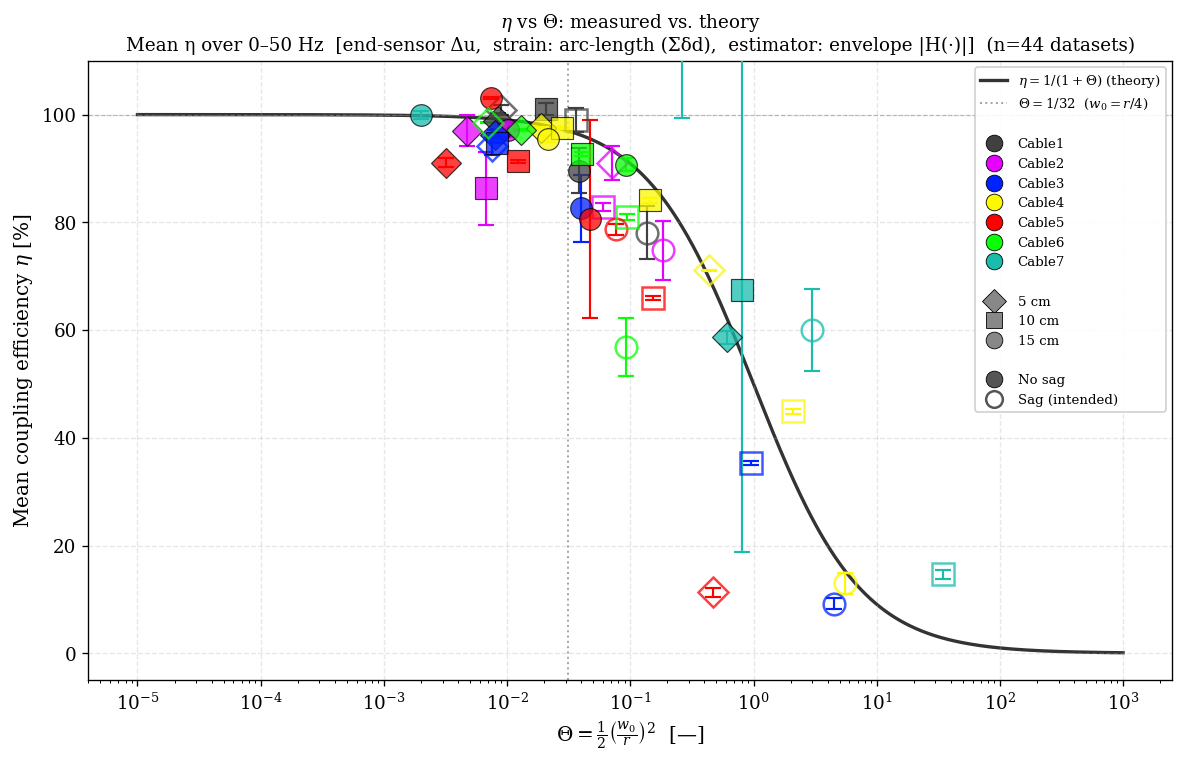

In [15]:
plotting.plot_eta_vs_theta(
    DATASETS,
    f_min=F_MIN, f_max=F_MAX,
    ref=REF,
    xlim=XLIM, ylim=YLIM,
    percent=PERCENT,
    show_errorbars=SHOW_ERRORBARS,
    show_theory=True,
    strain_method=STRAIN_METHOD,
    estimator=ESTIMATOR,
)


---
## Section 5  Summary table

All datasets sorted by Theta, with measured eta_mean and the theoretical
prediction eta_pred = 1/(1+Theta) for comparison.


In [ ]:
rows = []
key = (F_MIN, F_MAX, REF, STRAIN_METHOD, ESTIMATOR)
for cfg in DATASETS:
    d = cfg.get('eta_summary', {}).get(key)
    if d is None:
        continue
    rows.append({
        'Label': cfg['label'],
        'Cable': cfg.get('cable', '?'),
        'Gap [cm]': int(cfg['gap_m'] * 100),
        'Sag': 'yes' if 'Sag' in cfg['label'] else 'no',
        'Theta': round(cfg['theta_pred'], 5),
        'eta_pred [%]': round(cfg['eta_pred'] * 100, 2),
        f'eta_mean [%] ({F_MIN:.0f}-{F_MAX:.0f} Hz)': round(d['eta_mean'] * 100, 2),
        'eta_std [%]': round(d['eta_std'] * 100, 2),
        'n_freqs': d['n_freqs'],
    })

df = pd.DataFrame(rows).sort_values('Theta').reset_index(drop=True)
from IPython.display import display
display(df.style
    .format({'Theta': '{:.5f}',
             'eta_pred [%]': '{:.2f}',
             f'eta_mean [%] ({F_MIN:.0f}-{F_MAX:.0f} Hz)': '{:.2f}',
             'eta_std [%]': '{:.2f}'})
    .background_gradient(subset=[f'eta_mean [%] ({F_MIN:.0f}-{F_MAX:.0f} Hz)'],
                         cmap='RdYlGn', vmin=0, vmax=100)
    .set_caption(f'Mean coupling efficiency (ref: {REF}, strain: {STRAIN_METHOD}, '
                 f'estimator: {ESTIMATOR}, {F_MIN:.0f}-{F_MAX:.0f} Hz)'))


---
## Section 6  Explore individual frequency bands

Run the same plot for several frequency bands side by side to see
whether the eta-vs-Theta relationship changes with frequency.
Results for already-computed frequencies are reused from the cache.


In [ ]:
# Define multiple bands to compare
BANDS = [
    (0,   50),
    (50,  150),
    (150, 300),
    (300, 500),
]

for f_lo, f_hi in BANDS:
    for cfg in DATASETS:
        for method in ["arclength", "gradient"]:
            for est in ["instantaneous", "envelope"]:
                analysis.compute_mean_eta(cfg, f_min=f_lo, f_max=f_hi,
                                           ref=REF, strain_method=method,
                                           estimator=est, verbose=False)
    for method in ["arclength", "gradient"]:
        for est in ["instantaneous", "envelope"]:
            plotting.plot_eta_vs_theta(
                DATASETS, f_min=f_lo, f_max=f_hi,
                ref=REF,
                xlim=XLIM, ylim=(-30, 150),
                percent=PERCENT,
                show_errorbars=SHOW_ERRORBARS,
                strain_method=method,
                estimator=est,
            )
